In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- Cài đặt TensorFlow ---
!pip install tensorflow numpy pandas librosa scikit-learn psutil matplotlib tqdm  keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 7.1 MB/s eta 0:00:00


In [ ]:

import os
import time
import warnings
from datetime import datetime

import pandas as pd
import numpy as np
import joblib
import psutil
import json

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm # Theo dõi tiến trình


COVER_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/Data/musdb18-hq'
STEGO_FOLDER = '/content/drive/MyDrive/HK1-20252026/Steganography/PSR-LSB_AUDIO_2025-11-21_20-41-03/Temp_Stego'
OUTPUT_DIR = '/content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB'


TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
rp = f'CNN/{TIMESTAMP}'
Report_Dir = os.path.join(OUTPUT_DIR, rp)

# Khởi tạo Thư mục Output
os.makedirs(os.path.join(OUTPUT_DIR, 'CNN'), exist_ok=True)
os.makedirs(Report_Dir, exist_ok=True)

# Định nghĩa Tên File
SPECTROGRAM_FILE = os.path.join(OUTPUT_DIR, 'new_cnn_spectrograms.npz')


MODEL_FILE_CNN_DEFAULT = os.path.join(Report_Dir, 'cnn_model_default.keras')
MODEL_FILE_CNN_TUNED = os.path.join(Report_Dir, 'cnn_model_tuned.keras')
MODEL_FILE_CNN_TUNED_KT = os.path.join(Report_Dir, 'cnn_model_keras_tuner.keras')

JSON_REPORT_FILE_CNN_DEFAULT = os.path.join(Report_Dir, f'report_CNN_default_{TIMESTAMP}.json')
JSON_REPORT_FILE_CNN_TUNED = os.path.join(Report_Dir, f'report_CNN_tuned_{TIMESTAMP}.json')
JSON_REPORT_FILE_CNN_TUNED_KT = os.path.join(Report_Dir, f'report_CNN_keras_tuner_{TIMESTAMP}.json')

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings('ignore', category=RuntimeWarning)

In [ ]:
import numpy as np
import librosa
from scipy import signal

def audio_to_melspectrogram(file_path, n_mels=128, fmax=8000, fixed_length=216):
    try:
        # 1. Đọc file audio (5 giây đầu)
        y, sr = librosa.load(file_path, sr=None, duration=5.0)
        if len(y) < 5 * sr:
            y = np.tile(y, int(np.ceil((5 * sr) / len(y))))
        y = y[:5 * sr]


        sos = signal.butter(10, 2000, 'hp', fs=sr, output='sos')
        y = signal.sosfilt(sos, y)


        # Tạo Mel Spectrogram
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, fmax=fmax)
        S_db = librosa.power_to_db(S, ref=np.max)

        # Cố định kích thước (Padding/Cutting)
        if S_db.shape[1] > fixed_length:
            S_db = S_db[:, :fixed_length]
        else:
            pad_width = fixed_length - S_db.shape[1]
            S_db = np.pad(S_db, pad_width=((0, 0), (0, pad_width)), mode='constant')

        return S_db
    except Exception as e:
        print(f"Lỗi tạo spectrogram cho {file_path}: {e}")
        return None

def load_spectrogram_data(cover_folder, stego_folder, spectrogram_file):
    if os.path.exists(spectrogram_file):
        print(f" Tải dữ liệu spectrogram từ file '{spectrogram_file}'...")
        data = np.load(spectrogram_file)
        return data['spectrograms'], data['labels']
    else:
        print(f" Không tìm thấy file spectrogram. Bắt đầu tạo mới (có lọc nhiễu)...")
        spectrograms, labels, files_to_process = [], [], []

        for root, _, files in os.walk(cover_folder):
            for f in files:
                if f.endswith(('.wav', '.mp3', '.flac')):
                    files_to_process.append({'path': os.path.join(root, f), 'label': 0})
        for root, _, files in os.walk(stego_folder):
            for f in files:
                if f.endswith(('.wav', '.mp3', '.flac')):
                    files_to_process.append({'path': os.path.join(root, f), 'label': 1})

        for file_info in tqdm(files_to_process, desc="Xử lý Audio"):
            spec = audio_to_melspectrogram(file_info['path'])
            if spec is not None:
                spectrograms.append(spec)
                labels.append(file_info['label'])

        X_spec = np.array(spectrograms)
        y_spec = np.array(labels)

        print(f"Lưu spectrogram vào file '{spectrogram_file}'...")
        np.savez_compressed(spectrogram_file, spectrograms=X_spec, labels=y_spec)
        return X_spec, y_spec



X_spectrograms, y_labels = load_spectrogram_data(COVER_FOLDER, STEGO_FOLDER, SPECTROGRAM_FILE)
print(f"\nTổng cộng {X_spectrograms.shape[0]} spectrogram. Kích thước: {X_spectrograms.shape[1:]}")

X_spectrograms = X_spectrograms[..., np.newaxis]
mean_val = np.mean(X_spectrograms)
std_val = np.std(X_spectrograms)
X_spectrograms = (X_spectrograms - mean_val) / (std_val + 1e-7)
print(f"Đã chuẩn hóa: Mean={mean_val:.2f}, Std={std_val:.2f}")

# Chia train/test
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_spectrograms, y_labels, test_size=0.3, random_state=42, stratify=y_labels
)
input_shape = X_train_img.shape[1:]

 Tải dữ liệu spectrogram từ file '/content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/new_cnn_spectrograms.npz'...

Tổng cộng 1500 spectrogram. Kích thước: (128, 216)
Đã chuẩn hóa: Mean=-41.22, Std=30.80


In [ ]:
print(f"Input shape: {input_shape}")

Input shape: (128, 216, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import psutil
import json
import numpy as np
import os  # Đã thêm
from datetime import datetime # Đã thêm

def run_cnn_default_experiment(model_name, build_fn_params, model_file, report_file,
                               X_train, y_train, X_test, y_test,
                               epochs=30, batch_size=32, threshold=0.5): # Thêm tham số threshold
    print("\n" + "="*60)
    print(f"BẮT ĐẦU QUY TRÌNH CHO: {model_name.upper()}")
    print("="*60)

    log_data = {}
    process = psutil.Process(os.getpid())
    start_time_model = time.time()

    print(f"-> Xây dựng và huấn luyện mô hình {model_name}...")

    # Hàm xây dựng model nội bộ
    def build_default_cnn(input_shape, conv1_filters, conv2_filters, dense_units, dropout_rate, learning_rate):
        model = Sequential([
            Input(shape=input_shape),

            Conv2D(filters=conv1_filters, kernel_size=(3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Conv2D(filters=conv2_filters, kernel_size=(3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            MaxPooling2D((2, 2)),

            Flatten(),
            Dense(dense_units, activation='relu'),
            Dropout(dropout_rate),
            Dense(1, activation='sigmoid')
        ])

        optimizer = Adam(learning_rate=learning_rate)
        model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
        return model

    # Gọi hàm build
    model = build_default_cnn(input_shape=X_train.shape[1:], **build_fn_params)
    model.summary()

    # --- Huấn luyện ---
    mem_before_train = process.memory_info().rss
    start_time_train = time.time()

    early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping, reduce_lr],
        verbose=1
    )

    training_duration = time.time() - start_time_train
    mem_after_train = process.memory_info().rss
    training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)
    print(f"Huấn luyện hoàn tất sau {training_duration:.2f} giây.")

    # Log thông tin huấn luyện
    actual_params = {
        'epochs_run': len(history.history['loss']),
        'batch_size': batch_size,
        'optimizer_config': model.optimizer.get_config(),
        'loss_function': getattr(model.loss, '__name__', str(model.loss)),
        'model_architecture_params': build_fn_params
    }

    log_data['training_info'] = {
        'status': f'Trained model ({model_name})',
        'model_class': 'Sequential_CNN',
        'training_duration_seconds': round(training_duration, 2),
        'training_memory_increase_mb': round(training_memory_increase_mb, 2),
        'all_model_params': actual_params
    }

    model.save(model_file)
    print(f"Đã lưu mô hình Keras vào file: {model_file}")
    print(f"\n--- Đánh giá hiệu năng mô hình {model_name} (Threshold: {threshold}) ---")

    # Dự đoán trên tập Train
    start_time_pred_train = time.time()
    y_train_pred_proba = model.predict(X_train, verbose=0) # verbose=0 để gọn output
    y_train_pred = (y_train_pred_proba > threshold).astype(int).flatten()
    pred_train_duration = time.time() - start_time_pred_train
    train_accuracy = accuracy_score(y_train, y_train_pred)

    # Dự đoán trên tập Test
    start_time_pred_test = time.time()
    y_test_pred_proba = model.predict(X_test, verbose=0)
    y_test_pred = (y_test_pred_proba > threshold).astype(int).flatten()
    pred_test_duration = time.time() - start_time_pred_test
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"\nĐộ chính xác trên tập Train: {train_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Train:")
    print(classification_report(y_train, y_train_pred, target_names=['Cover (0)', 'Stego (1)'], zero_division=0))

    print(f"\nĐộ chính xác trên tập Test: {test_accuracy:.4f}")
    print("Báo cáo chi tiết trên tập Test:")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)'], zero_division=0))

    print(f"Thời gian dự đoán trên tập Test: {pred_test_duration:.4f} giây")

    # Vẽ Confusion Matrix
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover (0)', 'Stego (1)'], cmap=plt.cm.Blues, ax=ax)
    plt.title(f"Ma trận nhầm lẫn - Test ({model_name})")
    plt.show()

    execution_time = time.time() - start_time_model

    # Log kết quả
    log_data['evaluation_results'] = {
        'threshold_used': threshold,
        'train_set': {
            'accuracy': train_accuracy,
            'classification_report': classification_report(y_train, y_train_pred, output_dict=True, zero_division=0),
            'prediction_duration_seconds': round(pred_train_duration, 4)
        },
        'test_set': {
            'accuracy': test_accuracy,
            'classification_report': classification_report(y_test, y_test_pred, output_dict=True, zero_division=0),
            'prediction_duration_seconds': round(pred_test_duration, 4)
        }
    }
    log_data['run_info'] = {
        'timestamp': datetime.now().isoformat(),
        'execution_duration_seconds': round(execution_time, 2)
    }

    # Serializer JSON
    def default_serializer(o):
        if isinstance(o, (np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64)): return int(o)
        elif isinstance(o, (np.float_, np.float16, np.float32, np.float64)): return float(o)
        elif isinstance(o, (np.ndarray,)): return o.tolist()
        try: return str(o)
        except Exception: return repr(o)

    with open(report_file, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False, default=default_serializer)
    print(f"Đã lưu báo cáo chi tiết vào file: {report_file}")


BẮT ĐẦU QUY TRÌNH CHO: CNN_DEFAULT
-> Xây dựng và huấn luyện mô hình CNN_Default...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 110592)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │    14,155,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,175,233 (54.07 MB)

 Trainable params: 14,175,041 (54.07 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 205ms/step - accuracy: 0.5405 - loss: 3.2387 - val_accuracy: 0.4689 - val_loss: 1.0783 - learning_rate: 1.0000e-04
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.6123 - loss: 1.1692 - val_accuracy: 0.4911 - val_loss: 1.3464 - learning_rate: 1.0000e-04
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6130 - loss: 0.5883 - val_accuracy: 0.5000 - val_loss: 1.1997 - learning_rate: 1.0000e-04
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6377 - loss: 0.5275 - val_accuracy: 0.5000 - val_loss: 1.6657 - learning_rate: 1.0000e-04
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6371 - loss: 0.5228 - val_accuracy: 0.4978 - val_loss: 1.6308 - learning_rate: 1.0000e-04
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6555 - loss: 0.5058
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6550 - l

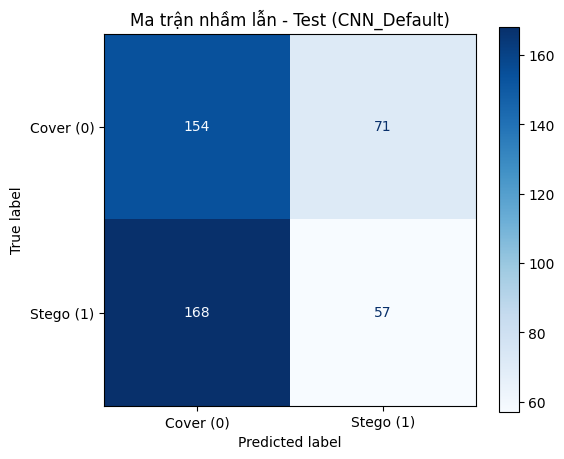

Đã lưu báo cáo chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/CNN/20251122_160338/report_CNN_default_20251122_160338.json


In [ ]:

default_cnn_params = {
    'conv1_filters': 32, 'conv2_filters': 64, 'dense_units': 128
    , 'dropout_rate': 0.25, 'learning_rate': 0.0001
}
run_cnn_default_experiment(
    model_name='CNN_Default', build_fn_params=default_cnn_params,
    model_file=MODEL_FILE_CNN_DEFAULT, report_file=JSON_REPORT_FILE_CNN_DEFAULT,
    X_train=X_train_img, y_train=y_train, X_test=X_test_img, y_test=y_test,
    epochs=30
)

Trial 5 Complete [00h 00m 47s]
val_accuracy: 0.54666668176651

Best val_accuracy So Far: 0.6222222447395325
Total elapsed time: 00h 04m 18s

Best Hyperparameters: {'filters_1': 16, 'dropout_1': 0.2, 'filters_2': 96, 'filters_3': 128, 'dense_units': 256, 'learning_rate': 0.001}

Dang huan luyen lai mo hinh tot nhat...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 19s 166ms/step - accuracy: 0.5449 - loss: 0.9073 - val_accuracy: 0.5000 - val_loss: 4.7133 - learning_rate: 0.0010
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5899 - loss: 0.7580 - val_accuracy: 0.5000 - val_loss: 5.5864 - learning_rate: 0.0010
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.6238 - loss: 0.7073 - val_accuracy: 0.5000 - val_loss: 1.6895 - learning_rate: 0.0010
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.6264 - loss: 0.6874 - val_accuracy: 0.5000 - val_loss: 0.8860 - learning_rate: 0.0010
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.6051 - los

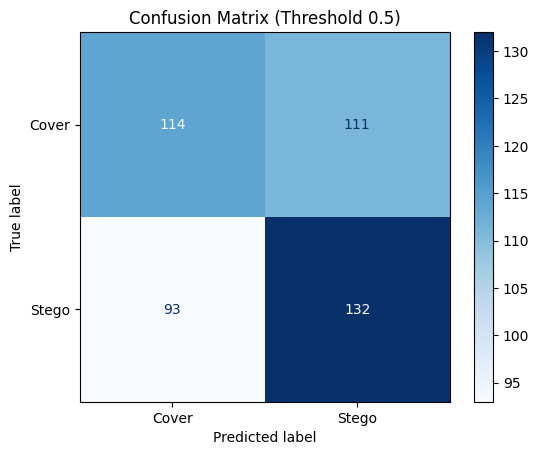


Da luu bao cao chi tiet (JSON) vao: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/CNN/20251122_160338/report_CNN_tuned_20251122_160338.json
Da luu toan bo ket qua vao thu muc: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/CNN/20251122_160338


In [ ]:
import os
import time
import json
import numpy as np
import psutil
from datetime import datetime
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Import Keras Tuner
import keras_tuner as kt

# Xoa session cu de giai phong bo nho
tf.keras.backend.clear_session()

# Ham serializer cho JSON (xu ly cac kieu du lieu numpy)
def default_serializer(o):
    if isinstance(o, (np.int_, np.intc, np.intp, np.int8, np.int16, np.int32, np.int64, np.uint8, np.uint16, np.uint32, np.uint64)): return int(o)
    elif isinstance(o, (np.float_, np.float16, np.float32, np.float64)): return float(o)
    elif isinstance(o, (np.ndarray,)): return o.tolist()
    try: return str(o)
    except Exception: return repr(o)


def build_model(hp):
    # Luu y: input_shape phai duoc dinh nghia truoc do (VD: input_shape = (128, 128, 3))
    model = Sequential()
    model.add(Input(shape=input_shape))

    hp_filters1 = hp.Int('filters_1', min_value=16, max_value=64, step=16)
    model.add(Conv2D(hp_filters1, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))

    # Tuner thử Dropout từ 0.2 đến 0.4
    hp_dropout1 = hp.Float('dropout_1', min_value=0.2, max_value=0.4, step=0.1)
    model.add(Dropout(hp_dropout1))

    # Block 2: Filters tăng dần (ví dụ: 32 -> 64 -> 128)
    hp_filters2 = hp.Int('filters_2', min_value=32, max_value=128, step=32)
    model.add(Conv2D(hp_filters2, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(hp_dropout1))

    # Block 3
    hp_filters3 = hp.Int('filters_3', min_value=64, max_value=256, step=64)
    model.add(Conv2D(hp_filters3, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D((2, 2)))
    model.add(Dropout(hp_dropout1 + 0.1)) # Dropout cao hơn ở lớp sâu

    model.add(Flatten())

    # --- Tinh chỉnh lớp Dense ---
    hp_dense = hp.Int('dense_units', min_value=64, max_value=256, step=64)
    model.add(Dense(hp_dense, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Dense(1, activation='sigmoid'))

    # --- Tinh chỉnh Learning Rate (3 giá trị) ---
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=Adam(learning_rate=hp_learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model



# Kiem tra xem du lieu da duoc load chua
if 'X_train_img' in globals() and 'y_train' in globals():
    print("\nBAT DAU HUAN LUYEN (CAU HINH CAN BANG)...")

    process = psutil.Process(os.getpid())
    mem_before_train = process.memory_info().rss
    start_time_total = time.time()

    # Dam bao thu muc output ton tai
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    # 1. Thiet lap Tuner
    tuner = kt.RandomSearch(
        build_model,
        objective='val_accuracy',
        max_trials=5,
        executions_per_trial=1,
        directory=os.path.join(OUTPUT_DIR, 'tuner_logs'),
        project_name='cnn_balanced_run_v2',
        overwrite=True
    )

    # 2. Tim kiem tham so
    tuner.search(
        X_train_img, y_train,
        epochs=15,
        batch_size=16,
        validation_data=(X_test_img, y_test),
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    )

    # 3. Lay tham so tot nhat
    best_hps = tuner.get_best_hyperparameters()[0]
    best_params_values = best_hps.values
    print(f"\nBest Hyperparameters: {best_params_values}")

    # 4. Huan luyen lai (Retrain)
    print("\nDang huan luyen lai mo hinh tot nhat...")
    model = tuner.hypermodel.build(best_hps)

    start_time_train = time.time()
    BATCH_SIZE = 16
    history = model.fit(
        X_train_img, y_train,
        epochs=30,
        batch_size=BATCH_SIZE,
        validation_data=(X_test_img, y_test),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ],
        verbose=1
    )
    training_duration = time.time() - start_time_train

    mem_after_train = process.memory_info().rss
    training_memory_increase_mb = (mem_after_train - mem_before_train) / (1024 * 1024)

    # 5. Luu Model
    # Dam bao thu muc chua model ton tai
    model_dir = os.path.dirname(MODEL_FILE_CNN_TUNED_KT)
    if not os.path.exists(model_dir):
        os.makedirs(model_dir)

    model.save(MODEL_FILE_CNN_TUNED_KT)
    print(f"Da luu model vao: {MODEL_FILE_CNN_TUNED_KT}")



    # Train set
    start_time_pred_train = time.time()
    y_train_pred_proba = model.predict(X_train_img)
    pred_train_duration = time.time() - start_time_pred_train

    # Test set
    start_time_pred_test = time.time()
    y_test_pred_proba = model.predict(X_test_img)
    pred_test_duration = time.time() - start_time_pred_test

    # Ap dung threshold 0.5
    threshold = 0.5
    y_train_pred = (y_train_pred_proba > threshold).astype(int).flatten()
    y_test_pred = (y_test_pred_proba > threshold).astype(int).flatten()

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)

    print(f"Test Accuracy: {test_accuracy:.4f}")
    print(classification_report(y_test, y_test_pred, target_names=['Cover (0)', 'Stego (1)']))

    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Cover', 'Stego'], cmap=plt.cm.Blues)
    plt.title("Confusion Matrix (Threshold 0.5)")
    plt.show()



    # Lay thong tin optimizer config
    optimizer_config = model.optimizer.get_config() if hasattr(model.optimizer, 'get_config') else {}

    log_data = {
        "training_info": {
            "status": "Trained model (CNN_Keras_Tuner)",
            "model_class": "Sequential_CNN",
            "training_duration_seconds": round(training_duration, 2),
            "training_memory_increase_mb": round(training_memory_increase_mb, 2),
            "all_model_params": {
                "epochs_run": len(history.history['loss']),
                "batch_size": BATCH_SIZE,
                "optimizer_config": optimizer_config,
                "loss_function": "binary_crossentropy",
                "model_architecture_params": best_params_values
            }
        },
        "evaluation_results": {
            "train_set": {
                "accuracy": float(train_accuracy),
                "classification_report": classification_report(y_train, y_train_pred, output_dict=True),
                "prediction_duration_seconds": round(pred_train_duration, 4)
            },
            "test_set": {
                "accuracy": float(test_accuracy),
                "classification_report": classification_report(y_test, y_test_pred, output_dict=True),
                "prediction_duration_seconds": round(pred_test_duration, 4)
            }
        },
        "run_info": {
            "timestamp": datetime.now().isoformat(),
            "execution_duration_seconds": round(time.time() - start_time_total, 2)
        }
    }

    # Dam bao thu muc report ton tai
    if not os.path.exists(Report_Dir):
        os.makedirs(Report_Dir)

    json_report_path = os.path.join(Report_Dir, f'report_CNN_tuned_{TIMESTAMP}.json')

    with open(json_report_path, 'w', encoding='utf-8') as f:
        json.dump(log_data, f, indent=4, ensure_ascii=False, default=default_serializer)

    print(f"\nDa luu bao cao chi tiet (JSON) vao: {json_report_path}")
    print(f"Da luu toan bo ket qua vao thu muc: {Report_Dir}")

else:
    print("\nKHONG TIM THAY DU LIEU. Vui long chay lai Cell load du lieu (dam bao bien X_train_img va y_train da duoc khoi tao).")


BẮT ĐẦU QUY TRÌNH CHO: CNN_DEFAULT
-> Xây dựng và huấn luyện mô hình CNN_Default...


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 216, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 216, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 108, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 108, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 108, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 110592)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    14,155,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,175,233 (54.07 MB)

 Trainable params: 14,175,041 (54.07 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 151ms/step - accuracy: 0.5906 - loss: 3.6620 - val_accuracy: 0.5644 - val_loss: 0.6657 - learning_rate: 1.0000e-04
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6332 - loss: 1.1994 - val_accuracy: 0.5756 - val_loss: 0.6822 - learning_rate: 1.0000e-04
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6388 - loss: 0.6714 - val_accuracy: 0.4978 - val_loss: 0.7321 - learning_rate: 1.0000e-04
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6593 - loss: 0.5669 - val_accuracy: 0.6089 - val_loss: 0.7571 - learning_rate: 1.0000e-04
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6281 - loss: 0.5431 - val_accuracy: 0.6089 - val_loss: 0.7342 - learning_rate: 1.0000e-04
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6435 - loss: 0.5281
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6434 - l

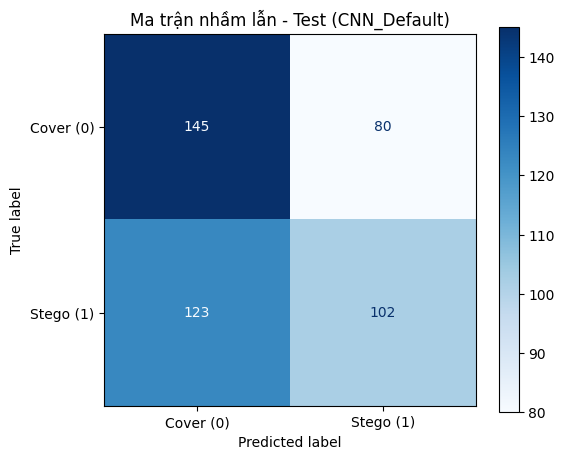

Đã lưu báo cáo chi tiết vào file: /content/drive/MyDrive/HK1-20252026/ClassifyStego/PSR-LSB/CNN/20251122_160338/report_CNN_default_20251122_160338.json


In [ ]:

default_cnn_params = {
    'conv1_filters': 32, 'conv2_filters': 64, 'dense_units': 128
    , 'dropout_rate': 0.25, 'learning_rate': 0.0001
}
run_cnn_default_experiment(
    model_name='CNN_Default', build_fn_params=default_cnn_params,
    model_file=MODEL_FILE_CNN_DEFAULT, report_file=JSON_REPORT_FILE_CNN_DEFAULT,
    X_train=X_train_img, y_train=y_train, X_test=X_test_img, y_test=y_test,
    epochs=30
)